# 🚴 Scraping - BikeclubPedalazo

Extrae **todos los productos** (nombre, marca, precio, tag) de `bikeclubpedalazo.online/productos.html`.

La página carga con **JavaScript**, por eso usamos **Selenium** en vez de solo `requests`.

| Herramienta | Para qué |
|---|---|
| `selenium` | Abrir navegador headless y esperar que cargue el JS |
| `beautifulsoup4` | Parsear el HTML resultante |
| `pandas` | Organizar y exportar datos |

In [27]:
# ── CELDA 1: Instalar Chrome de Google (no chromium snap) ─
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb -q
!pip install selenium webdriver-manager beautifulsoup4 pandas lxml -q
print('✅ Listo')

Reading package lists...
Building dependency tree...
Reading state information...
google-chrome-stable is already the newest version (148.0.7778.96-1).
0 upgraded, 0 newly installed, 0 to remove and 13 not upgraded.
✅ Listo


In [28]:
# ── CELDA 2: Imports ──────────────────────────────────────
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

print('✅ Imports OK')

✅ Imports OK


In [29]:
# ── CELDA 3: Configuración ────────────────────────────────
URL_BASE = 'https://www.bikeclubpedalazo.online/productos.html'

# Tiempo de espera máximo (segundos) para que carguen los productos
WAIT_TIMEOUT = 15

# Pausa entre scroll / entre páginas (segundos)
PAUSA = 2

In [30]:
# ── CELDA 4: Driver con Google Chrome ────────────────────
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

def crear_driver():
    opts = Options()
    opts.add_argument('--headless=new')
    opts.add_argument('--no-sandbox')
    opts.add_argument('--disable-dev-shm-usage')
    opts.add_argument('--disable-gpu')
    opts.add_argument('--window-size=1280,900')
    # Google Chrome real, no chromium snap
    opts.binary_location = '/usr/bin/google-chrome'

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=opts)
    return driver

driver = crear_driver()
print('✅ Chrome headless iniciado')

✅ Chrome headless iniciado


In [31]:
# ── CELDA 5: Extraer productos de UNA página ─────────────
def extraer_productos_de_pagina(html):
    """Parsea el HTML y retorna lista de dicts con los datos de cada producto."""
    soup = BeautifulSoup(html, 'lxml')
    articulos = soup.find_all('article', class_='product-card')

    productos = []
    for art in articulos:
        # Marca
        marca_tag = art.find('div', class_='product-card__brand')
        marca = marca_tag.text.strip() if marca_tag else ''

        # Nombre
        nombre_tag = art.find('h3', class_='product-card__title')
        nombre = nombre_tag.text.strip() if nombre_tag else ''

        # Precio
        precio_tag = art.find('span', class_='product-card__price')
        precio = precio_tag.text.strip() if precio_tag else ''

        # Tag (Nuevo, Oferta, etc.)
        tag_el = art.find('span', class_='product-card__tag')
        tag = tag_el.text.strip() if tag_el else ''

        # Link detalle
        link_tag = art.find('a')
        link = 'https://www.bikeclubpedalazo.online' + link_tag['href'] if link_tag and link_tag.get('href') else ''

        productos.append({
            'marca':  marca,
            'nombre': nombre,
            'precio': precio,
            'tag':    tag,
            'link':   link
        })

    return productos

print('✅ Función definida')

✅ Función definida


In [32]:
# ── CELDA 7: SCRAPING CON PAGINACIÓN POR BOTONES ─────────
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

todos_productos = []

driver.get(URL_BASE)

# Esperar carga inicial
WebDriverWait(driver, WAIT_TIMEOUT).until(
    EC.presence_of_element_located((By.CLASS_NAME, 'product-card'))
)
time.sleep(2)

# Contar cuántas páginas hay
botones = driver.find_elements(By.CSS_SELECTOR, '#paginationControls .pagination-btn')
# Filtrar solo los numéricos (excluir ← y →)
nums = []
for btn in botones:
    txt = btn.text.strip()
    if txt.isdigit():
        nums.append(int(txt))

total_paginas = max(nums) if nums else 1
print(f'Total páginas detectadas: {total_paginas}')

# Iterar cada página
for pagina in range(1, total_paginas + 1):
    print(f'\nPágina {pagina}/{total_paginas}...')

    # Clicar botón con ese número
    try:
        btn = driver.find_element(
            By.XPATH,
            f'//div[@id="paginationControls"]//button[text()="{pagina}"]'
        )
        driver.execute_script('arguments[0].click();', btn)
    except Exception as e:
        print(f'  ⚠️ No se encontró botón {pagina}: {e}')
        continue

    # Esperar que carguen los nuevos productos
    time.sleep(2)

    # Extraer productos de esta página
    prods = extraer_productos_de_pagina(driver.page_source)
    todos_productos.extend(prods)
    print(f'  ✅ {len(prods)} productos extraídos')

print(f'\n🎉 Total general: {len(todos_productos)} productos')

Total páginas detectadas: 6

Página 1/6...
  ✅ 12 productos extraídos

Página 2/6...
  ✅ 12 productos extraídos

Página 3/6...
  ✅ 12 productos extraídos

Página 4/6...
  ✅ 12 productos extraídos

Página 5/6...
  ✅ 12 productos extraídos

Página 6/6...
  ✅ 12 productos extraídos

🎉 Total general: 72 productos


In [33]:
# ── CELDA 8: Ver resultados ───────────────────────────────
df = pd.DataFrame(todos_productos)

# Limpiar precios: quitar $, puntos, espacios → número
df['precio_num'] = (
    df['precio']
    .str.replace(r'[\$\s]', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

print(f'Total productos: {len(df)}')
print(f'Precio mín: {df["precio_num"].min():,.0f}')
print(f'Precio máx: {df["precio_num"].max():,.0f}')
print(f'Precio prom: {df["precio_num"].mean():,.0f}\n')

display(df.head(20))

Total productos: 72
Precio mín: 10,000
Precio máx: 24,679,999
Precio prom: 690,986



,marca,nombre,precio,tag,link,precio_num
0,Shimano,JUEGO DE BIELAS FC-R8100 ULTEGRA 52-36T 12V SH...,$ 799.000,Nuevo,,799000
1,GW,BICICLETA BMX/DIRT 20P DESTRUCTOR ACERO GW,$ 764.998,Nuevo,,764998
2,Syncros,SOPORTE CICLOCOMPUTADOR Y LUZ/GO PRO IC AERO S...,$ 380.000,Nuevo,,380000
3,SCOTT,BICICLETA RUTA FOIL RC 10 2024/2025,$ 24.679.999,Nuevo,,24679999
4,Shimano,JUEGO DE BIELAS FC-R3000 SORA 34-50T 9V SHIMANO,$ 390.000,Nuevo,,390000
5,Chaoyang,LLANTA MTB 29X2.0 60TPI H-5196TR VICTORY II PL...,$ 75.000,Nuevo,,75000
6,GW,BOLSO PORTAHERRAMIENTAS ROLL UP GW,$ 58.000,Nuevo,,58000
7,Shimano,PLATO FC-M4100-2 DEORE 36T-BF 10V SHIMANO,$ 60.000,Nuevo,,60000
8,Shimano,PALANCAS DE FRENO BL-M9200 L/R XTR SHIMANO,$ 750.000,Nuevo,,750000
9,Shimano,CABLE DE FRENO TRASERO 1.5X2100MM 7X7 ACERO,$ 38.000,Nuevo,,38000


In [34]:
# ── CELDA 9: Exportar ─────────────────────────────────────
# CSV
df.to_csv('productos_bikeclubpedalazo.csv', index=False, encoding='utf-8-sig')
print('✅ CSV guardado')

# Excel
df.to_excel('productos_bikeclubpedalazo.xlsx', index=False)
print('✅ Excel guardado')

# Descargar ambos en Colab
from google.colab import files
files.download('productos_bikeclubpedalazo.csv')
files.download('productos_bikeclubpedalazo.xlsx')

✅ CSV guardado
✅ Excel guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# ── CELDA 10: Cerrar navegador ────────────────────────────
driver.quit()
print('✅ Chrome cerrado')

✅ Chrome cerrado


---
## 🔧 Diagnóstico (si algo falla)

Celdas para depurar problemas.

In [36]:
# DIAG 1: Ver HTML crudo de la página (buscar clases reales)
# Ejecutar si productos = 0

driver2 = crear_driver()
driver2.get(URL_BASE)
time.sleep(5)
html = driver2.page_source
driver2.quit()

from bs4 import BeautifulSoup
soup = BeautifulSoup(html, 'lxml')

# Buscar todos los article
arts = soup.find_all('article')
print(f'Total <article>: {len(arts)}')
if arts:
    print('\nPrimer article:')
    print(arts[0].prettify()[:1000])

# Buscar por precio ($)
precios = soup.find_all(string=lambda t: t and '$' in t)
print(f'\nElementos con $: {len(precios)}')
for p in precios[:5]:
    print(f'  "{p.strip()}" → <{p.parent.name} class="{p.parent.get("class")}">')

Total <article>: 12

Primer article:
<article class="card product-card fade-up-anim">
 <div class="product-card__image">
  <img alt="JUEGO DE BIELAS FC-R8100 ULTEGRA 52-36T 12V SHIMANO" class="product-card__img" loading="lazy" src="

Elementos con $: 12
  "$ 799.000" → <span class="['product-card__price']">
  "$ 764.998" → <span class="['product-card__price']">
  "$ 380.000" → <span class="['product-card__price']">
  "$ 24.679.999" → <span class="['product-card__price']">
  "$ 390.000" → <span class="['product-card__price']">


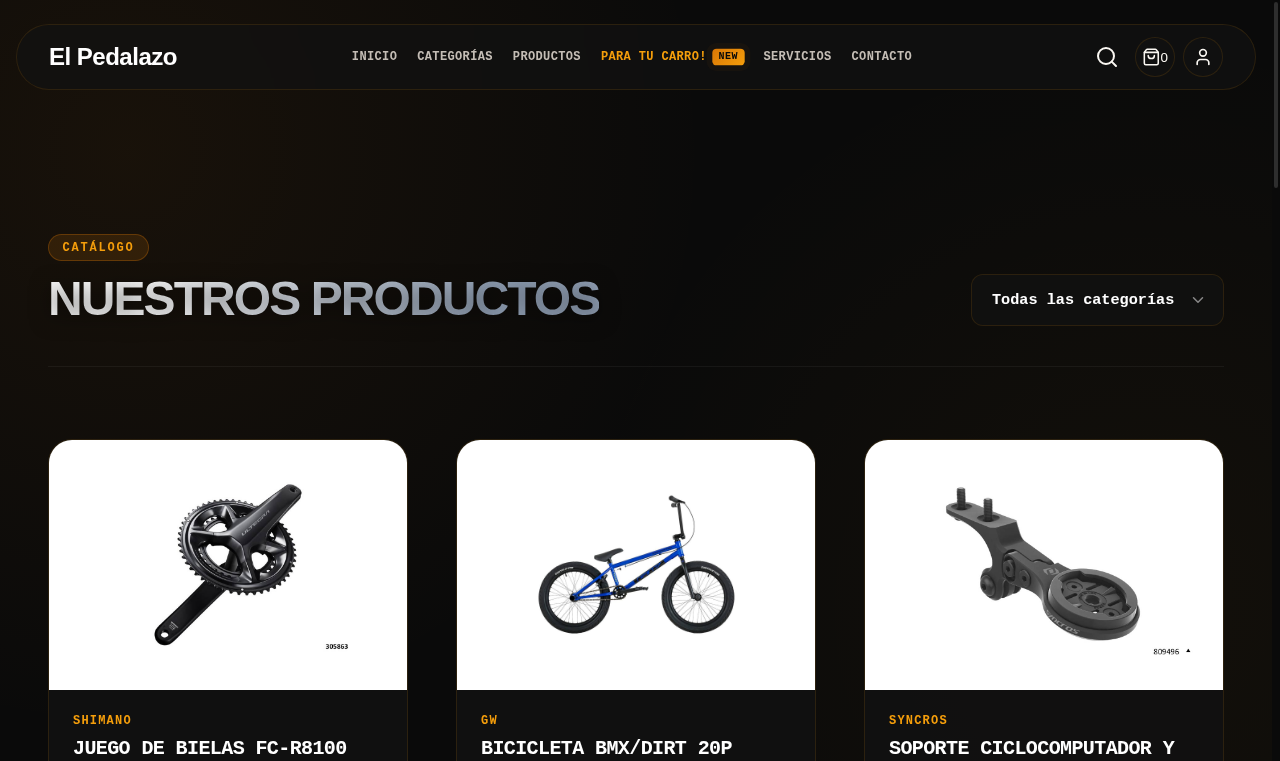

In [37]:
# DIAG 2: Screenshot de la página (ver qué renderiza Chrome)
from IPython.display import Image

driver3 = crear_driver()
driver3.get(URL_BASE)
time.sleep(5)
driver3.save_screenshot('screenshot.png')
driver3.quit()

display(Image('screenshot.png'))